# Linear Probe Scaling Curves: Collect per-experiment metric files and plot

Reads `*.txt` metric files saved by `2026-04-15_15-30_compute_linear_probe_metrics.py` and
plots noise-scaling curves (x = quality, lines = sizes) for each dataset and algorithm.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')

ALGOS = ['Geneformer', 'PCA', 'RandomProjection', 'SCVI', 'State']
ALGO_ORDER = ['State', 'Geneformer', 'SCVI', 'PCA']

EXPECTED = {
    'PBMC': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422, 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0],
        'task': 'regression',
    },
    'larry': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.003876, 0.0071835, 0.0133136, 0.0246748, 0.0457311, 0.0847557, 0.1570821, 0.2911284, 0.5395631, 1.0],
        'task': 'regression',
    },
    'merfish': {
        'sizes': [100, 203, 414, 843, 1716, 3494, 7113, 14480, 29475, 60000],
        'qualities': [0.027248, 0.0406617, 0.0606789, 0.0905502, 0.1351267, 0.2016475, 0.3009156, 0.4490518, 0.6701133, 1.0],
        'task': 'regression',
    },
    'shendure': {
        'sizes': [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000],
        'qualities': [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384, 0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0],
        'task': 'classification',
    },
}

# Metrics to look for per task type
REGRESSION_METRICS = ['ridge_mean_r2', 'ridge_mean_mse', 'ridge_mean_mae']
CLASSIFICATION_METRICS = ['knn_accuracy', 'knn_macro_f1', 'logreg_accuracy', 'logreg_macro_f1']

## Collect metric files from disk

In [2]:
from itertools import product
from concurrent.futures import ThreadPoolExecutor
import os

# Build expected grid: one row per (dataset, algo, size, quality) with the metric files we expect
expected_rows = []
for ds, cfg in EXPECTED.items():
    metric_names = CLASSIFICATION_METRICS if cfg['task'] == 'classification' else REGRESSION_METRICS
    for algo, size, quality in product(ALGOS, cfg['sizes'], cfg['qualities']):
        model_dir = DATA_ROOT / ds / str(size) / str(quality) / 'results' / algo / 'model'
        # We consider the experiment "found" if at least one metric file exists
        expected_rows.append({
            'dataset': ds, 'algorithm': algo, 'size': size, 'quality': quality,
            'task': cfg['task'], 'model_dir': str(model_dir),
            'metric_names': metric_names,
        })

df_expected = pd.DataFrame(expected_rows)
print(f'Total expected experiments: {len(df_expected)}')

# Check which have at least one metric .txt file
def _has_any_metric(row):
    d = Path(row['model_dir'])
    return any((d / f'{m}.txt').exists() for m in row['metric_names'])

with ThreadPoolExecutor(max_workers=128) as pool:
    df_expected['exists'] = list(tqdm(
        pool.map(lambda i: _has_any_metric(df_expected.iloc[i]), range(len(df_expected))),
        total=len(df_expected), desc='Scanning'))

print(f"Found: {df_expected['exists'].sum()}, Missing: {(~df_expected['exists']).sum()}")

Total expected experiments: 2000


Scanning:   0%|          | 0/2000 [00:00<?, ?it/s]

Scanning: 100%|██████████| 2000/2000 [00:00<00:00, 515049.30it/s]

Found: 1000, Missing: 1000


In [3]:
# Completeness table: found / expected / missing per dataset x algorithm
pivot = df_expected.groupby(['dataset', 'algorithm'])['exists'].agg(['sum', 'count'])
pivot.columns = ['found', 'expected']
pivot['missing'] = pivot['expected'] - pivot['found']
pivot = pivot.astype(int)

pivot_wide = pivot.unstack('algorithm', fill_value=0).sort_index()
pivot_wide = pivot_wide.reindex(columns=pivot_wide.columns.reindex(
    ALGO_ORDER, level='algorithm')[0])
display(pivot_wide)

found                      expected                      missing  \
algorithm State Geneformer SCVI  PCA    State Geneformer SCVI  PCA   State   
dataset                                                                      
PBMC        100        100  100  100      100        100  100  100       0   
larry         0          0    0    0      100        100  100  100     100   
merfish       0          0    0    0      100        100  100  100     100   
shendure    100        100  100  100      100        100  100  100       0   

                                
algorithm Geneformer SCVI  PCA  
dataset                         
PBMC               0    0    0  
larry            100  100  100  
merfish          100  100  100  
shendure           0    0    0

## Read metric values

In [4]:
# Read actual metric values from found experiments
rows = []
df_found = df_expected[df_expected['exists']].copy()
for _, exp in tqdm(df_found.iterrows(), total=len(df_found), desc='Reading metrics'):
    model_dir = Path(exp['model_dir'])
    row = {
        'dataset': exp['dataset'], 'algorithm': exp['algorithm'],
        'size': exp['size'], 'quality': exp['quality'], 'task': exp['task'],
    }
    for metric in exp['metric_names']:
        fpath = model_dir / f'{metric}.txt'
        if fpath.exists():
            row[metric] = float(fpath.read_text().strip())
        else:
            row[metric] = np.nan
    rows.append(row)

df = pd.DataFrame(rows)
print(f'Collected {len(df)} results')
df.head()

Reading metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

Reading metrics:  58%|█████▊    | 582/1000 [00:00<00:00, 5813.93it/s]

Reading metrics: 100%|██████████| 1000/1000 [00:00<00:00, 5496.41it/s]

Collected 1000 results


,dataset,algorithm,size,quality,task,ridge_mean_r2,ridge_mean_mse,ridge_mean_mae,knn_accuracy,knn_macro_f1,logreg_accuracy,logreg_macro_f1
0,PBMC,Geneformer,100,0.001235,regression,-0.162861,7532.277615,18.189933,NaN,NaN,NaN,NaN
1,PBMC,Geneformer,100,0.002598,regression,-0.209871,7303.046655,17.456674,NaN,NaN,NaN,NaN
2,PBMC,Geneformer,100,0.005468,regression,-0.016518,6923.395961,16.990701,NaN,NaN,NaN,NaN
3,PBMC,Geneformer,100,0.011508,regression,0.111950,6654.303639,16.531380,NaN,NaN,NaN,NaN
4,PBMC,Geneformer,100,0.024220,regression,0.110355,6481.801421,16.179610,NaN,NaN,NaN,NaN


## Noise scaling curves (metric vs quality, one line per size)

In [5]:
import matplotlib.ticker as mticker

DS_ORDER = ['PBMC', 'larry', 'merfish', 'shendure']


def _fmt_size(sz):
    """Human-readable size label: 100, 1k, 10k, 1M, 10M, etc."""
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)


def _plain_number(x, pos):
    """Format as plain number: 5000 not 5×10³."""
    if x == 0:
        return '0'
    if x >= 1:
        return f'{x:g}'
    return f'{x:g}'

In [6]:
# Combined figure: each row is one (dataset, metric) pair
# (dataset, metric_col, display_label, lower_is_better, pct, log_y)
ROW_SPECS = [
    ('PBMC',     'ridge_mean_r2',   'Ridge Mean R²',     False, False, False),
    ('larry',    'ridge_mean_r2',   'Ridge Mean R²',     False, False, False),
    ('merfish',  'ridge_mean_r2',   'Ridge Mean R²',     False, False, False),
    ('shendure', 'logreg_accuracy', 'LogReg Accuracy',   False, True,  False),
]

### Combined: R² (PBMC, larry, merfish) + Accuracy (shendure)

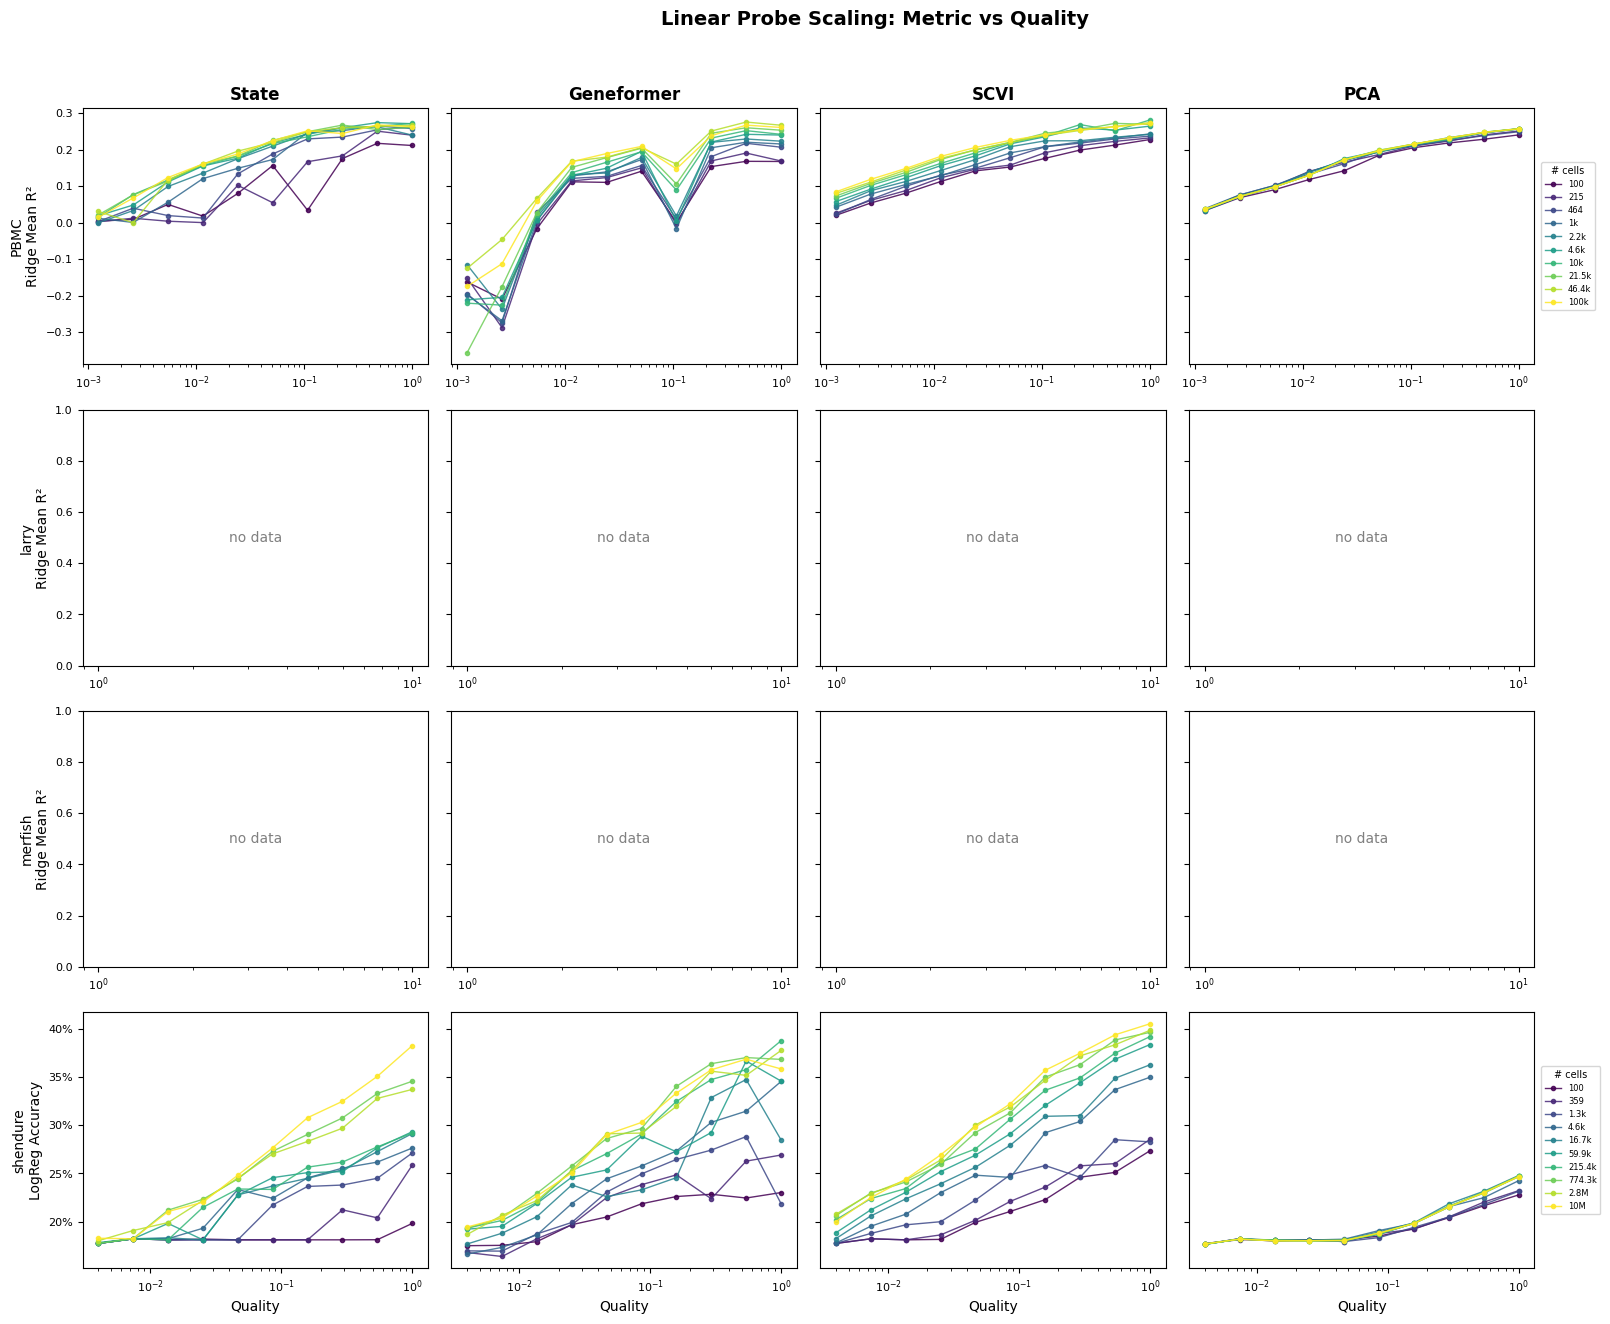

In [7]:
algorithms = [a for a in ALGO_ORDER if a in df['algorithm'].unique()]
n_rows = len(ROW_SPECS)
n_cols = len(algorithms)

plain_fmtr = mticker.FuncFormatter(_plain_number)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols + 1.6, 3.2 * n_rows + 0.8),
                         squeeze=False, sharex=False)

# Share y within each row (but not across rows — different metrics)
for i in range(n_rows):
    for j in range(1, n_cols):
        axes[i, j].sharey(axes[i, 0])

cmap = plt.cm.viridis

for i, (ds, metric_col, metric_label, lower_is_better, pct, log_y) in enumerate(ROW_SPECS):
    # Sizes and colornorm for this dataset
    sizes = sorted(df[df['dataset'] == ds]['size'].unique())
    norm = mcolors.LogNorm(vmin=min(sizes), vmax=max(sizes)) if sizes else None

    for j, algo in enumerate(algorithms):
        ax = axes[i, j]
        sub = df[(df['dataset'] == ds) & (df['algorithm'] == algo)].dropna(subset=[metric_col])

        if sub.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='gray', fontsize=10)
        else:
            for sz in sorted(sub['size'].unique()):
                color = cmap(norm(sz))
                sz_df = sub[sub['size'] == sz].sort_values('quality')
                y = sz_df[metric_col] * 100 if pct else sz_df[metric_col]
                ax.plot(sz_df['quality'], y,
                        marker='o', markersize=3, linewidth=1, color=color,
                        alpha=0.85, label=_fmt_size(sz))

        ax.set_xscale('log')
        if pct:
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
        elif log_y:
            ax.set_yscale('log')
            ax.yaxis.set_minor_formatter(mticker.NullFormatter())

        # x-label only on last row
        if i == n_rows - 1:
            ax.set_xlabel('Quality', fontsize=10)
        # y-label: dataset + metric subtitle
        if j == 0:
            ax.set_ylabel(f'{ds}\n{metric_label}', fontsize=10)
        # algo title on top row
        if i == 0:
            ax.set_title(algo, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=8)
        if j > 0:
            ax.tick_params(labelleft=False)

    # Invert y-axis ONCE on the lead axis (shared axes toggle on each call)
    if lower_is_better:
        axes[i, 0].invert_yaxis()

    # Legend to the right of last column per row
    last_ax = axes[i, n_cols - 1]
    handles, labels = last_ax.get_legend_handles_labels()
    if handles:
        last_ax.legend(handles, labels, title='# cells', fontsize=6,
                       title_fontsize=7, loc='center left',
                       bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                       frameon=True, framealpha=0.8)

fig.suptitle('Linear Probe Scaling: Metric vs Quality',
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0.01, 0.92, 0.96])
plt.show()

## Save plotted data to CSV and regenerate the plot from it

In [8]:
# Save the plotted data to CSV (long format: one row per dataset/algo/size/quality/probe)
FINAL_RESULTS = Path('/home/igor/noise_scaling/modeling/Scaling-up-measurement-noise-scaling-laws/analysis/final_results')
FINAL_RESULTS.mkdir(parents=True, exist_ok=True)
CSV_BASENAME = 'linear_probe_scaling'
CSV_PATH = FINAL_RESULTS / f'{CSV_BASENAME}.csv'
PNG_PATH = FINAL_RESULTS / f'{CSV_BASENAME}.png'

csv_rows = []
for ds, metric_col, *_ in ROW_SPECS:
    sub = df[df['dataset'] == ds][['dataset', 'algorithm', 'size', 'quality', metric_col]].dropna(subset=[metric_col])
    for _, r in sub.iterrows():
        csv_rows.append({
            'dataset': r['dataset'],
            'algo': r['algorithm'],
            'size': int(r['size']),
            'quality': float(r['quality']),
            'probe': metric_col,
            'value': float(r[metric_col]),
        })

csv_df = pd.DataFrame(csv_rows)
csv_df.to_csv(CSV_PATH, index=False)
print(f'Saved {len(csv_df)} rows to {CSV_PATH}')
csv_df.head()


Saved 1000 rows to /home/igor/noise_scaling/modeling/Scaling-up-measurement-noise-scaling-laws/analysis/final_results/linear_probe_scaling.csv


,dataset,algo,size,quality,probe,value
0,PBMC,Geneformer,100,0.001235,ridge_mean_r2,-0.162861
1,PBMC,Geneformer,100,0.002598,ridge_mean_r2,-0.209871
2,PBMC,Geneformer,100,0.005468,ridge_mean_r2,-0.016518
3,PBMC,Geneformer,100,0.011508,ridge_mean_r2,0.111950
4,PBMC,Geneformer,100,0.024220,ridge_mean_r2,0.110355


Saved figure to /home/igor/noise_scaling/modeling/Scaling-up-measurement-noise-scaling-laws/analysis/final_results/linear_probe_scaling.png


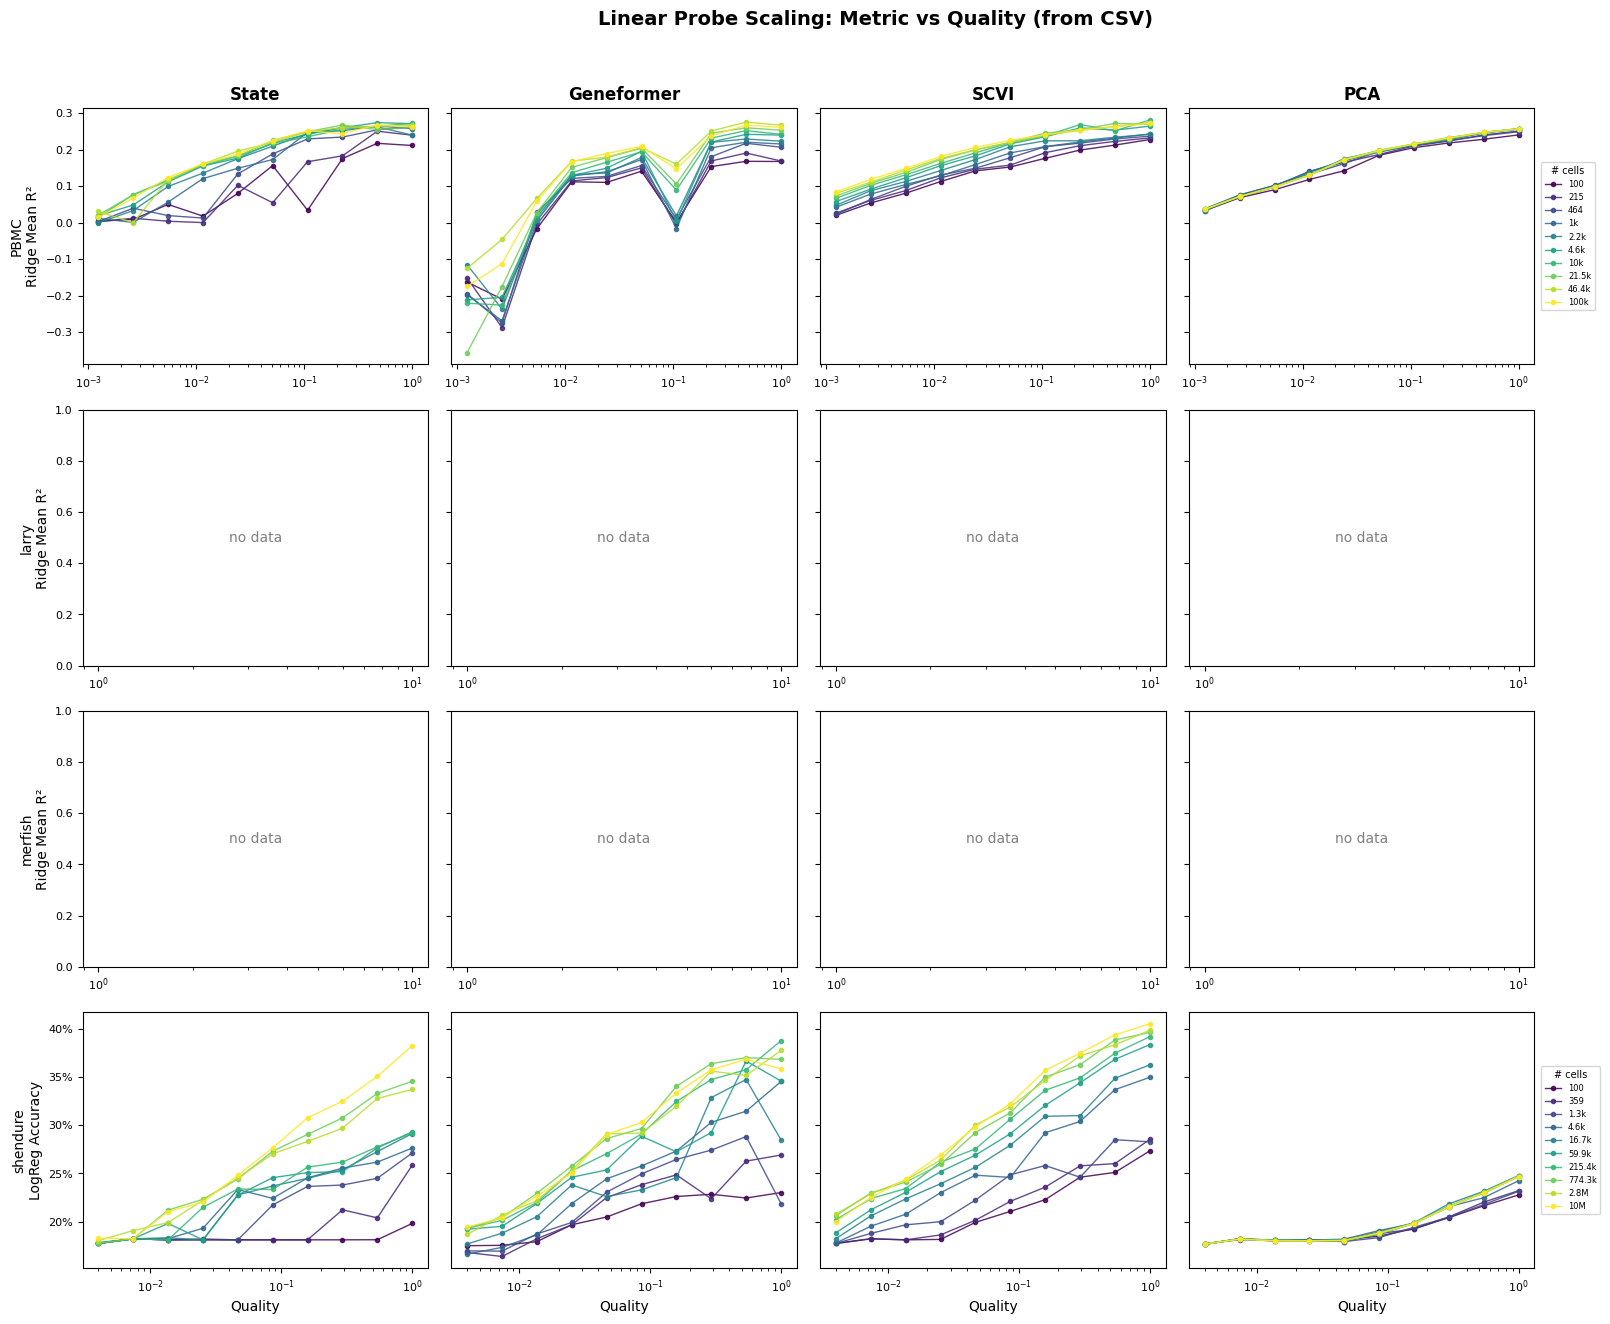

In [9]:
# Regenerate the plot from the saved CSV and write the PNG next to it
# (Plotting attributes — probe_label, lower_is_better, pct, log_y — live in ROW_SPECS, not the CSV.)
csv_df = pd.read_csv(CSV_PATH)

# Pivot to wide form (one column per probe) so the existing plotting logic works unchanged
df_from_csv = (csv_df
               .pivot_table(index=['dataset', 'algo', 'size', 'quality'],
                            columns='probe', values='value')
               .reset_index()
               .rename(columns={'algo': 'algorithm'}))
df_from_csv.columns.name = None

algorithms = [a for a in ALGO_ORDER if a in df_from_csv['algorithm'].unique()]
n_rows = len(ROW_SPECS)
n_cols = len(algorithms)

plain_fmtr = mticker.FuncFormatter(_plain_number)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols + 1.6, 3.2 * n_rows + 0.8),
                         squeeze=False, sharex=False)

for i in range(n_rows):
    for j in range(1, n_cols):
        axes[i, j].sharey(axes[i, 0])

cmap = plt.cm.viridis

for i, (ds, metric_col, metric_label, lower_is_better, pct, log_y) in enumerate(ROW_SPECS):
    sizes = sorted(df_from_csv[df_from_csv['dataset'] == ds]['size'].unique())
    norm = mcolors.LogNorm(vmin=min(sizes), vmax=max(sizes)) if sizes else None

    for j, algo in enumerate(algorithms):
        ax = axes[i, j]
        sub = df_from_csv[(df_from_csv['dataset'] == ds) & (df_from_csv['algorithm'] == algo)].dropna(subset=[metric_col])

        if sub.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='gray', fontsize=10)
        else:
            for sz in sorted(sub['size'].unique()):
                color = cmap(norm(sz))
                sz_df = sub[sub['size'] == sz].sort_values('quality')
                y = sz_df[metric_col] * 100 if pct else sz_df[metric_col]
                ax.plot(sz_df['quality'], y,
                        marker='o', markersize=3, linewidth=1, color=color,
                        alpha=0.85, label=_fmt_size(sz))

        ax.set_xscale('log')
        if pct:
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
        elif log_y:
            ax.set_yscale('log')
            ax.yaxis.set_minor_formatter(mticker.NullFormatter())

        if i == n_rows - 1:
            ax.set_xlabel('Quality', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'{ds}\n{metric_label}', fontsize=10)
        if i == 0:
            ax.set_title(algo, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=8)
        if j > 0:
            ax.tick_params(labelleft=False)

    if lower_is_better:
        axes[i, 0].invert_yaxis()

    last_ax = axes[i, n_cols - 1]
    handles, labels = last_ax.get_legend_handles_labels()
    if handles:
        last_ax.legend(handles, labels, title='# cells', fontsize=6,
                       title_fontsize=7, loc='center left',
                       bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                       frameon=True, framealpha=0.8)

fig.suptitle('Linear Probe Scaling: Metric vs Quality (from CSV)',
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0.01, 0.92, 0.96])
fig.savefig(PNG_PATH, dpi=200, bbox_inches='tight')
print(f'Saved figure to {PNG_PATH}')
plt.show()
